Cell 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
%matplotlib inline

Cell 2 — Load Datasets

In [6]:
print("Loading datasets...")

drug_names = pd.read_csv(r"C:\Users\MHGabAllah\Documents\AAA\project data\DEPI_Graduation\DEPI_Graduation\medical_project\drug_names.csv")
meddra_indications = pd.read_csv(r"C:\Users\MHGabAllah\Documents\AAA\project data\DEPI_Graduation\DEPI_Graduation\medical_project\meddra_all_indications_2.csv")
meddra_side_effects = pd.read_csv(r"C:\Users\MHGabAllah\Documents\AAA\project data\DEPI_Graduation\DEPI_Graduation\medical_project\meddra_side_effects.csv")
meddra_freq = pd.read_csv(r"C:\Users\MHGabAllah\Documents\AAA\project data\DEPI_Graduation\DEPI_Graduation\medical_project\meddra_freq.csv")
disease_symptoms = pd.read_csv(r"C:\Users\MHGabAllah\Documents\AAA\project data\DEPI_Graduation\DEPI_Graduation\medical_project\Disease and symptoms dataset.csv")

print("Datasets loaded successfully")

Loading datasets...
Datasets loaded successfully


Cell 3 — Data Overview

In [7]:
print("Drug names shape:", drug_names.shape)
print("Indications shape:", meddra_indications.shape)
print("Side effects shape:", meddra_side_effects.shape)
print("Frequency shape:", meddra_freq.shape)
print("Disease dataset shape:", disease_symptoms.shape)

Drug names shape: (1430, 2)
Indications shape: (30834, 2)
Side effects shape: (40838, 2)
Frequency shape: (39621, 3)
Disease dataset shape: (246945, 381)


Cell 4 — Clean Drug Data

In [8]:
drug_names = drug_names.drop_duplicates()
drug_names["drug_name"] = drug_names["drug_name"].str.strip()
print("Drug names cleaned")

Drug names cleaned


Cell 5 — Clean Indication Data

In [9]:
meddra_indications = meddra_indications.drop_duplicates()
meddra_indications["disease"] = meddra_indications["disease"].str.lower()
print("Indications cleaned")

Indications cleaned


Cell 6 — Clean Side Effect Data

In [10]:
meddra_side_effects = meddra_side_effects.drop_duplicates()
meddra_side_effects["side_effect"] = meddra_side_effects["side_effect"].str.lower()
print("Side effects cleaned")

Side effects cleaned


Cell 7 — Clean Frequency Data

In [11]:
meddra_freq = meddra_freq.drop_duplicates()
meddra_freq["Percentage"] = pd.to_numeric(meddra_freq["Percentage"], errors="coerce")
print("Frequency data cleaned")

Frequency data cleaned


Cell 8 — Clean Disease Symptoms Data

In [12]:
disease_symptoms = disease_symptoms.fillna(0)
print("Disease dataset cleaned")

Disease dataset cleaned


Cell 9 — Transform Symptoms (Wide → Long)

بنحول الـ dataset من 400 عمود لجدول طويل أسهل للتحليل — كل صف فيه مرض وعرض واحد

In [13]:
print("Transforming symptoms dataset...")

symptoms_long = disease_symptoms.melt(
    id_vars=["diseases"],
    var_name="symptom",
    value_name="present"
)

symptoms_long = symptoms_long[symptoms_long["present"] == 1]

print("Symptoms transformed")
print("New shape:", symptoms_long.shape)

Transforming symptoms dataset...
Symptoms transformed
New shape: (1316921, 3)


Cell 10 — Create SQL Database

In [14]:
print("Creating SQL database...")
engine = create_engine("sqlite:///medical_database.db")
print("Database created")

Creating SQL database...
Database created


Cell 11 — Save Tables to Database

In [15]:
print("Saving tables...")

drug_names.to_sql("drugs", engine, if_exists="replace", index=False)
meddra_indications.to_sql("drug_indications", engine, if_exists="replace", index=False)
meddra_side_effects.to_sql("drug_side_effects", engine, if_exists="replace", index=False)
meddra_freq.to_sql("side_effect_frequency", engine, if_exists="replace", index=False)
symptoms_long.to_sql("disease_symptoms", engine, if_exists="replace", index=False)

print("All tables saved successfully")

Saving tables...


All tables saved successfully


Cell 12 — Join Drug Data

In [16]:
print("Joining drug datasets...")

drug_full = drug_names.merge(meddra_indications, on="drug_id", how="left")
drug_full = drug_full.merge(meddra_side_effects, on="drug_id", how="left")

print("Drug datasets merged")
print("Shape:", drug_full.shape)

Joining drug datasets...
Drug datasets merged
Shape: (738834, 4)


Cell 13 — Save Merged Data

In [17]:
drug_full.to_sql("drug_complete_data", engine, if_exists="replace", index=False)
print("Merged dataset saved")

Merged dataset saved


Cell 14 — Basic Analysis

In [18]:
print("Running basic analysis...")

top_diseases = meddra_indications["disease"].value_counts().head(10)
print("\nTop diseases treated by drugs:")
print(top_diseases)

top_side_effects = meddra_side_effects["side_effect"].value_counts().head(10)
print("\nTop side effects:")
print(top_side_effects)

Running basic analysis...

Top diseases treated by drugs:
disease
infection                  213
renal failure              164
renal impairment           158
hypertension               143
neoplasm malignant         129
diabetes mellitus          118
liver disorder             102
pain                        95
neoplasm                    94
acute coronary syndrome     91
Name: count, dtype: int64

Top side effects:
side_effect
dizziness           329
nausea              315
headache            305
asthenia            282
rash                272
vomiting            268
urticaria           233
diarrhoea           233
hypersensitivity    226
pruritus            222
Name: count, dtype: int64


Cell 15 — Visualization

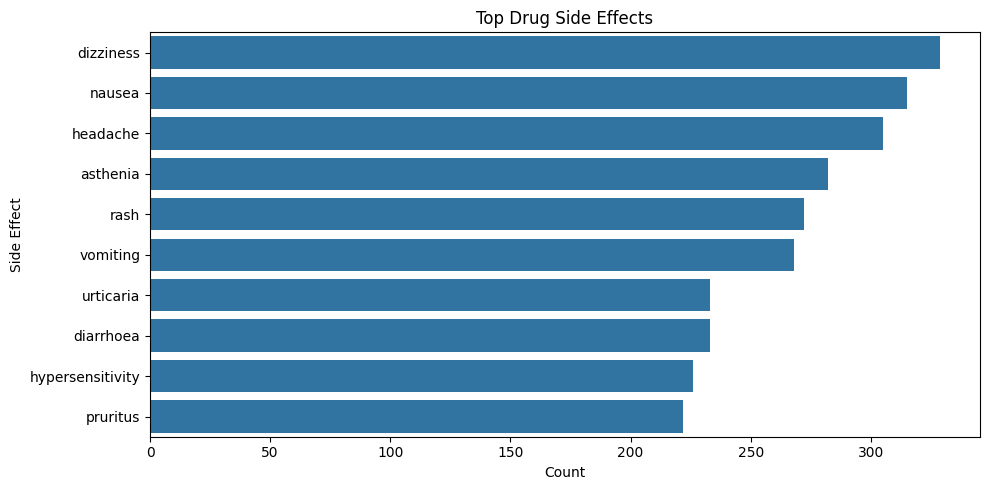

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_side_effects.values, y=top_side_effects.index)
plt.title("Top Drug Side Effects")
plt.xlabel("Count")
plt.ylabel("Side Effect")
plt.tight_layout()
plt.show()

Cell 16 — Export Clean Data

In [20]:
symptoms_long.to_csv("clean_disease_symptoms.csv", index=False)
drug_full.to_csv("clean_drug_data.csv", index=False)
print("Clean data exported")
print("\nPROJECT PIPELINE COMPLETED SUCCESSFULLY")

Clean data exported

PROJECT PIPELINE COMPLETED SUCCESSFULLY


Cell 17 — Top Diseases Chart

C:\Users\MHGabAllah\AppData\Local\Temp\ipykernel_19208\3864383981.py:27: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MHGabAllah\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


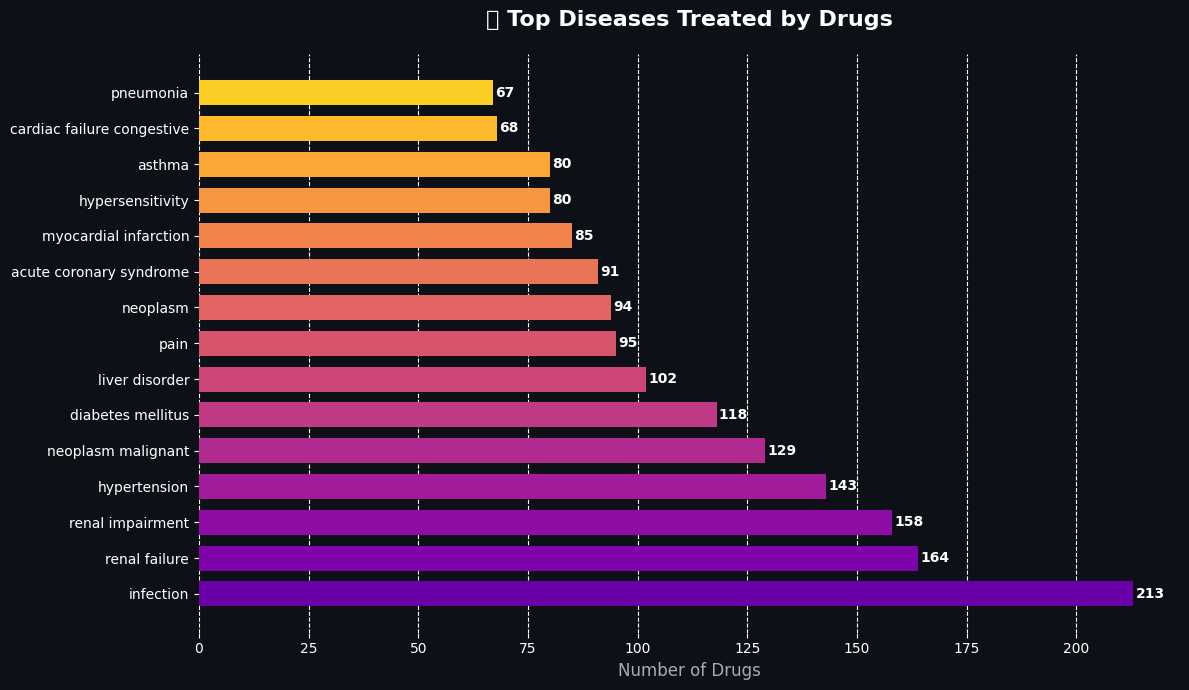

In [21]:
# =====================================================
# CELL 17 : TOP DISEASES
# أكثر الأمراض ارتباطاً بالأدوية
# =====================================================

top_diseases = meddra_indications["disease"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_diseases)))

bars = ax.barh(top_diseases.index, top_diseases.values, color=colors, edgecolor="none", height=0.7)

for bar, val in zip(bars, top_diseases.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", ha="left", color="white", fontsize=10, fontweight="bold")

ax.set_title("🏥 Top Diseases Treated by Drugs", color="white", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Number of Drugs", color="#aaaaaa", fontsize=12)
ax.tick_params(colors="white")
ax.spines[["top","right","bottom","left"]].set_visible(False)
ax.xaxis.grid(True, color="#ffffff22", linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Cell 18 — Drug Risk Score

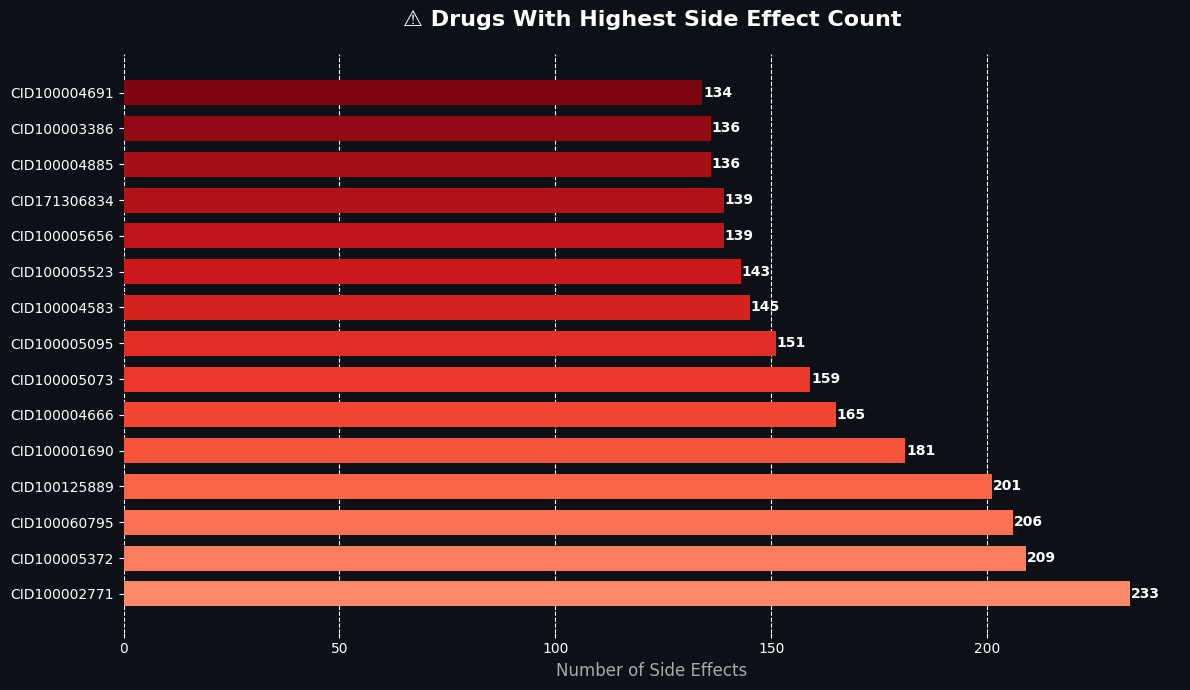

In [22]:
# =====================================================
# CELL 18 : DRUG RISK SCORE
# أكثر الأدوية خطورة من حيث الأعراض الجانبية
# =====================================================

drug_risk = (
    meddra_side_effects.groupby("drug_id")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

colors = plt.cm.Reds(np.linspace(0.4, 0.95, len(drug_risk)))

bars = ax.barh(drug_risk.index.astype(str), drug_risk.values, color=colors, edgecolor="none", height=0.7)

for bar, val in zip(bars, drug_risk.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", ha="left", color="white", fontsize=10, fontweight="bold")

ax.set_title("⚠️ Drugs With Highest Side Effect Count", color="white", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Number of Side Effects", color="#aaaaaa", fontsize=12)
ax.tick_params(colors="white")
ax.spines[["top","right","bottom","left"]].set_visible(False)
ax.xaxis.grid(True, color="#ffffff22", linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Cell 19 — Top Drugs Per Disease

C:\Users\MHGabAllah\AppData\Local\Temp\ipykernel_19208\1549109468.py:32: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MHGabAllah\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


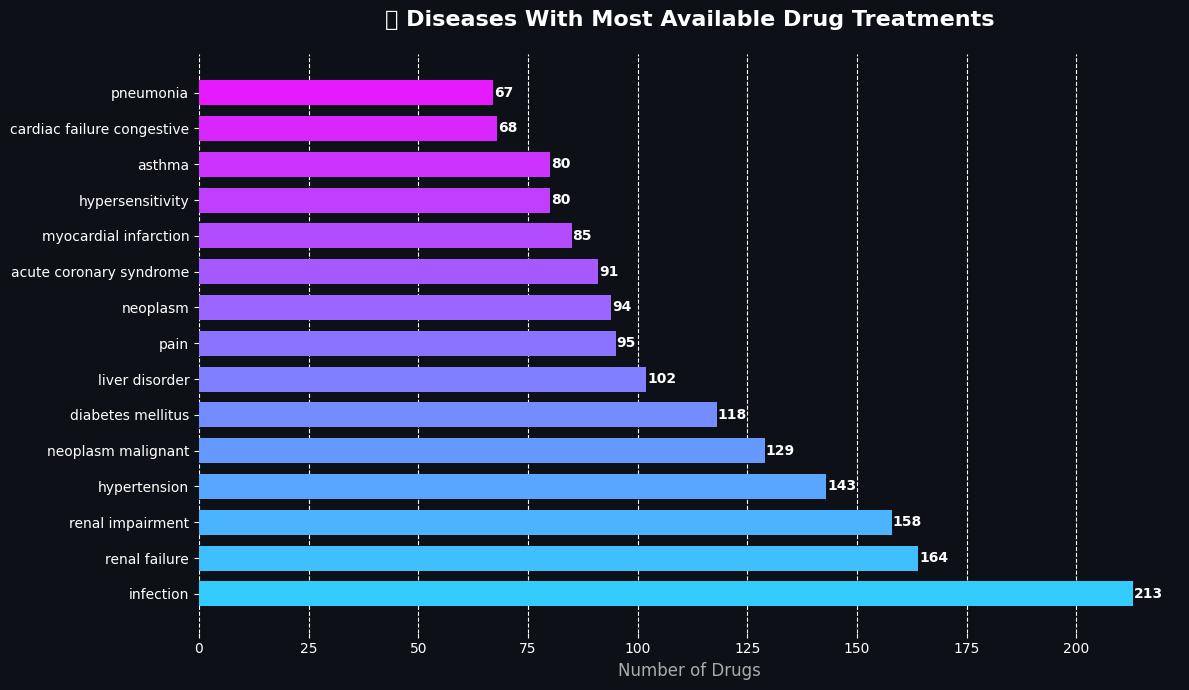

In [24]:
# =====================================================
# CELL 19 : TOP DRUGS PER DISEASE
# الأمراض التي لها أكثر عدد من الأدوية
# =====================================================

disease_drugs = (
    meddra_indications.groupby("disease")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

colors = plt.cm.cool(np.linspace(0.2, 0.9, len(disease_drugs)))

bars = ax.barh(disease_drugs.index, disease_drugs.values, color=colors, edgecolor="none", height=0.7)

for bar, val in zip(bars, disease_drugs.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", ha="left", color="white", fontsize=10, fontweight="bold")

ax.set_title("💊 Diseases With Most Available Drug Treatments", color="white", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Number of Drugs", color="#aaaaaa", fontsize=12)
ax.tick_params(colors="white")
ax.spines[["top","right","bottom","left"]].set_visible(False)
ax.xaxis.grid(True, color="#ffffff22", linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Cell 20 — Side Effect Frequency Distribution

C:\Users\MHGabAllah\AppData\Local\Temp\ipykernel_19208\818050266.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MHGabAllah\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


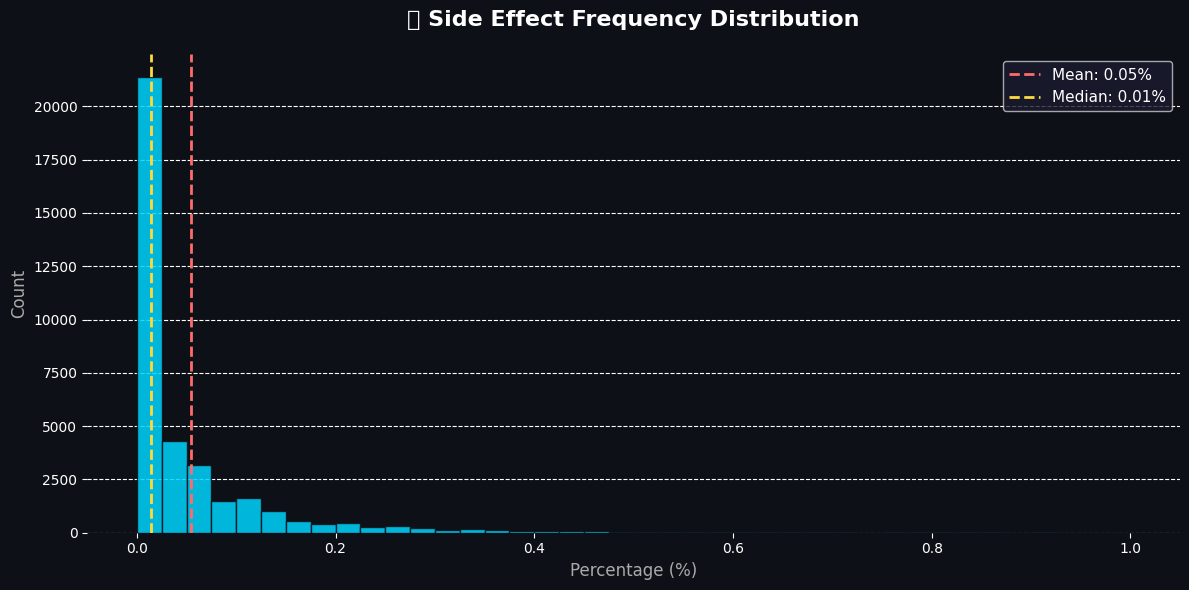

In [25]:
# =====================================================
# CELL 20 : FREQUENCY DISTRIBUTION
# توزيع نسب الأعراض الجانبية
# =====================================================

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

data = meddra_freq["Percentage"].dropna()

ax.hist(data, bins=40, color="#00d4ff", edgecolor="#0d1117", alpha=0.85)

ax.axvline(data.mean(), color="#ff6b6b", linestyle="--", linewidth=2, label=f"Mean: {data.mean():.2f}%")
ax.axvline(data.median(), color="#ffd93d", linestyle="--", linewidth=2, label=f"Median: {data.median():.2f}%")

ax.set_title("📊 Side Effect Frequency Distribution", color="white", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Percentage (%)", color="#aaaaaa", fontsize=12)
ax.set_ylabel("Count", color="#aaaaaa", fontsize=12)
ax.tick_params(colors="white")
ax.spines[["top","right","bottom","left"]].set_visible(False)
ax.yaxis.grid(True, color="#ffffff22", linestyle="--")
ax.set_axisbelow(True)
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=11)

plt.tight_layout()
plt.show()